<a href="https://colab.research.google.com/github/prince24-web/Mechine_learning/blob/main/Titanic_prediction_(decision_tree_vs_logistic_regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
Titanic_dataset = '/content/drive/My Drive/Titanic-Dataset.csv'

Mounted at /content/drive


In [12]:
#load the dataset
df = pd.read_csv(Titanic_dataset)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print("is categorical col: ",cat_col)
print("is numerical col: ",num_col)

is categorical col:  ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
is numerical col:  ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [14]:
df[cat_col].nunique()

,0
Name,891
Sex,2
Ticket,681
Cabin,147
Embarked,3


In [15]:
df[num_col].nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Age,88
SibSp,7
Parch,7
Fare,248


In [16]:
round(df.isnull().sum()/df.shape[0]*100,2)

,0
PassengerId,0.00
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,0.00


In [17]:
#drop irrelivant features
df1 = df.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns')
df1.fillna({'Age':df1['Age'].mean()}, inplace=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   Fare      891 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 34.9+ KB


### One-hot encode the 'Sex' column

In [18]:
df1 = pd.get_dummies(df1, columns=['Sex'], drop_first=True)
df1.head()

,Survived,Pclass,Age,Fare,Sex_male
0,0,3,22.0,7.2500,True
1,1,1,38.0,71.2833,False
2,1,3,26.0,7.9250,False
3,1,1,35.0,53.1000,False
4,0,3,35.0,8.0500,True


### Split data into training and testing sets

In [19]:
from sklearn.model_selection import train_test_split

X = df1.drop('Survived', axis=1)
y = df1['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (712, 4)
X_test shape: (179, 4)
y_train shape: (712,)
y_test shape: (179,)


### Train a Decision Tree Classifier

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Classifier Accuracy: {accuracy:.4f}")

Decision Tree Classifier Accuracy: 0.7542


### Visualize the Decision Tree

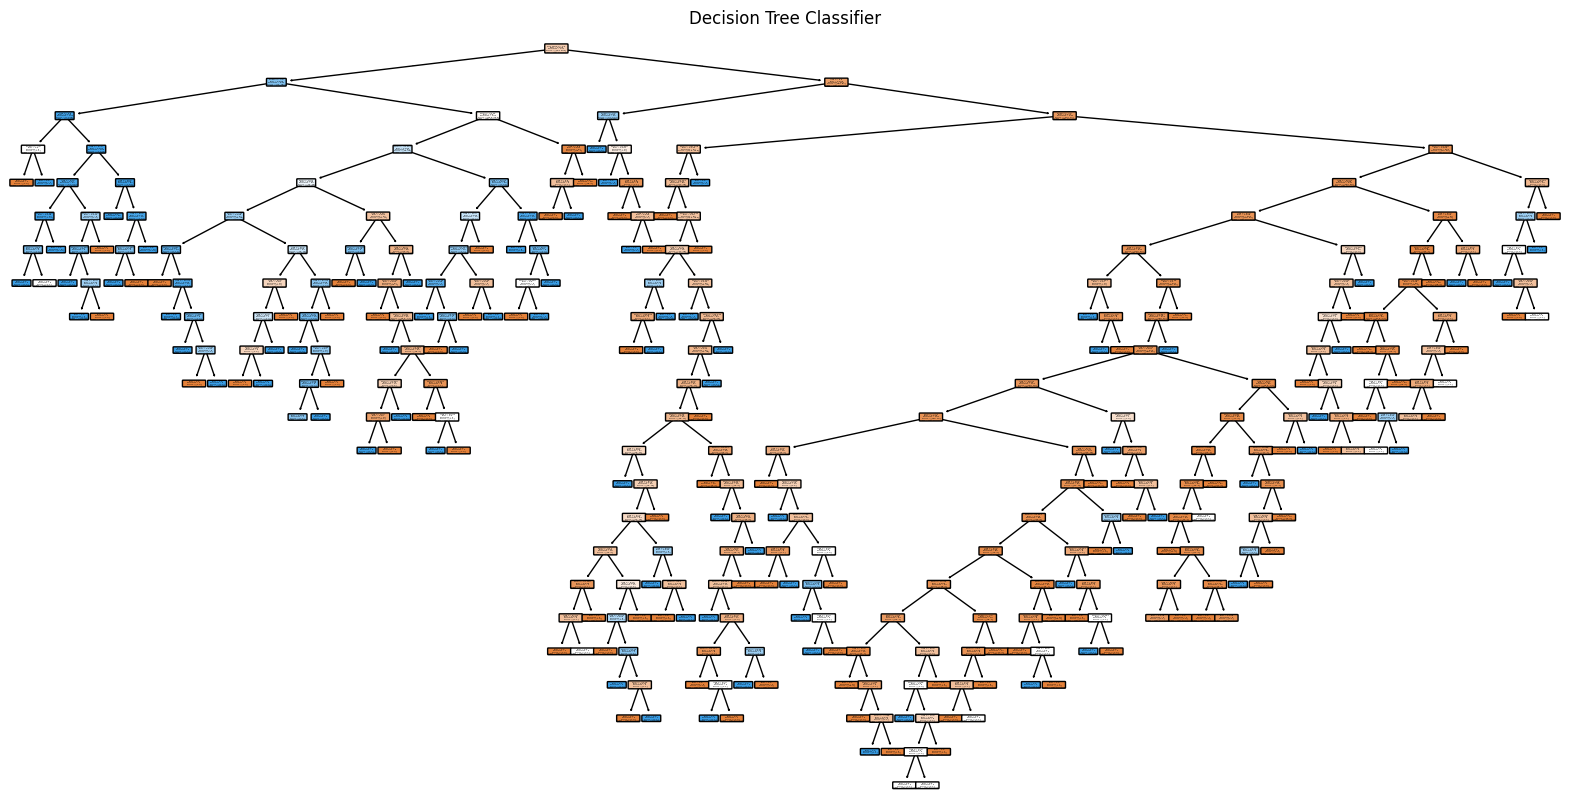

In [21]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtc, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True, rounded=True)
plt.title("Decision Tree Classifier");
plt.show()

### Compare Training vs. Test Accuracy

In [23]:
from sklearn.metrics import accuracy_score

# Training Accuracy
y_train_pred = dtc.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Decision Tree Classifier Training Accuracy: {train_accuracy:.4f}")

# Test Accuracy (already calculated, but displaying again for comparison)
print(f"Decision Tree Classifier Test Accuracy: {accuracy:.4f}")

Decision Tree Classifier Training Accuracy: 0.9789
Decision Tree Classifier Test Accuracy: 0.7542


### Retrain Decision Tree with Hyperparameter Tuning to Address Overfitting

To combat overfitting, we will limit the complexity of the tree by setting `max_depth`, `min_samples_split`, and `min_samples_leaf`.

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize the Decision Tree Classifier with pruned hyperparameters
# You can experiment with different values for these parameters
dtc_tuned = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)

# Train the tuned model
dtc_tuned.fit(X_train, y_train)

# Make predictions on the training set
y_train_pred_tuned = dtc_tuned.predict(X_train)
train_accuracy_tuned = accuracy_score(y_train, y_train_pred_tuned)

# Make predictions on the test set
y_test_pred_tuned = dtc_tuned.predict(X_test)
test_accuracy_tuned = accuracy_score(y_test, y_test_pred_tuned)

print(f"Tuned Decision Tree Classifier Training Accuracy: {train_accuracy_tuned:.4f}")
print(f"Tuned Decision Tree Classifier Test Accuracy: {test_accuracy_tuned:.4f}")

Tuned Decision Tree Classifier Training Accuracy: 0.8511
Tuned Decision Tree Classifier Test Accuracy: 0.8045


### Visualize the Tuned Decision Tree

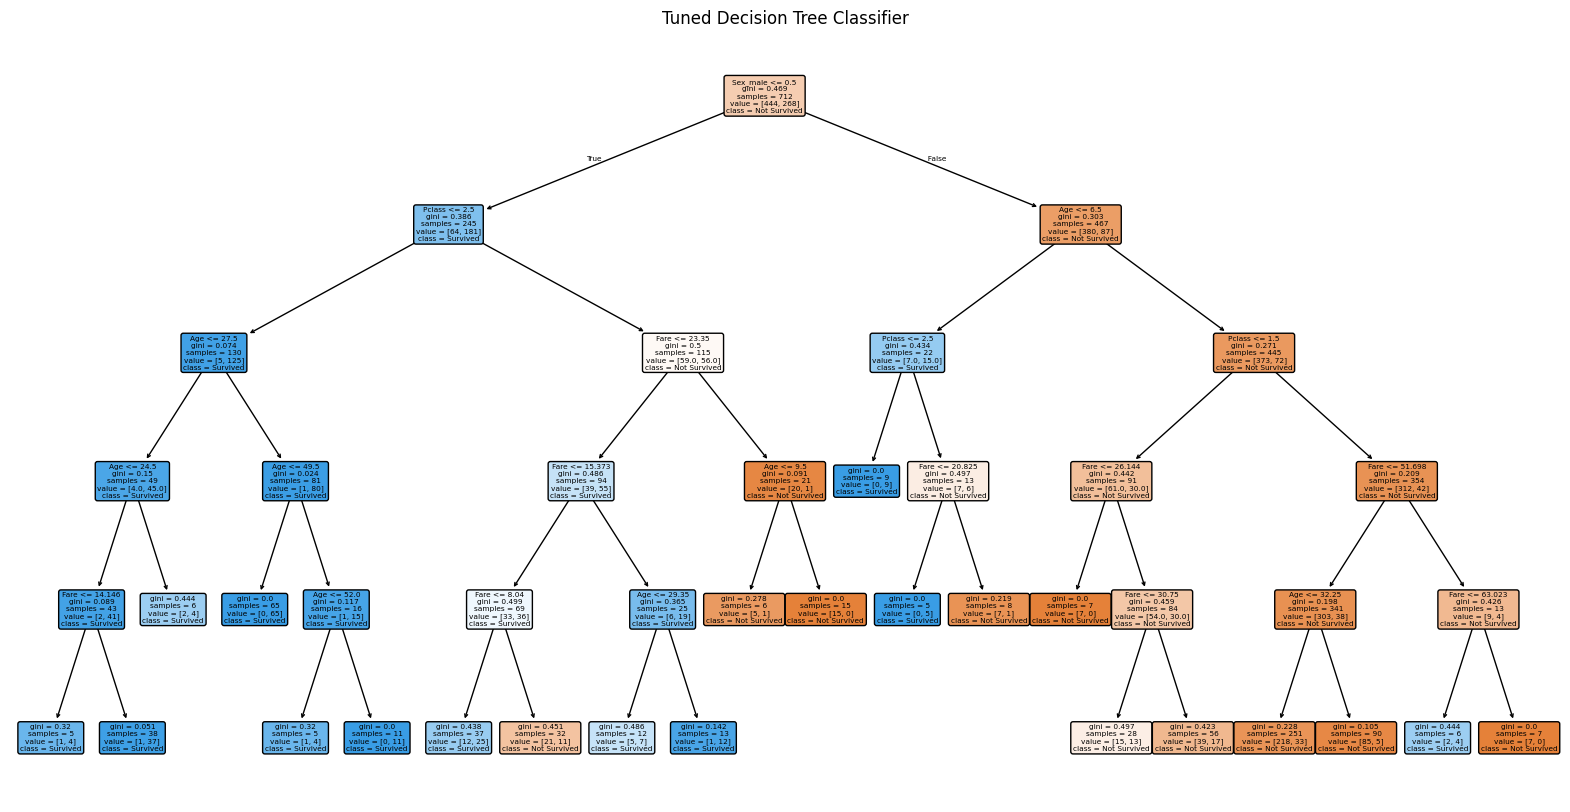

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtc_tuned, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True, rounded=True)
plt.title("Tuned Decision Tree Classifier");
plt.show()

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
LR_model = LogisticRegression(random_state=42,class_weight='balanced')
LR_model.fit(X_train, y_train)
y_pred = LR_model.predict(X_test)
y_pred_train = LR_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)
print("train accuracy ", train_accuracy)
accuracy = accuracy_score(y_test, y_pred)
print("accuracy ", accuracy)

train accuracy  0.7808988764044944
accuracy  0.8100558659217877


### Improve Accuracy: Feature Scaling (StandardScaler)

Logistic Regression models often benefit from feature scaling, as it helps the optimization algorithm converge more efficiently. We will apply `StandardScaler` to our features `X_train` and `X_test`.

In [31]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


### Retrain Logistic Regression with Scaled Data

Now, let's retrain the Logistic Regression model using the scaled features and check its accuracy.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize the Logistic Regression model again with scaled data
LR_model_scaled = LogisticRegression(random_state=42, class_weight='balanced')

# Train the model with scaled training data
LR_model_scaled.fit(X_train_scaled, y_train)

# Make predictions on scaled training data
y_train_pred_scaled = LR_model_scaled.predict(X_train_scaled)
train_accuracy_scaled = accuracy_score(y_train, y_train_pred_scaled)

# Make predictions on scaled test data
y_test_pred_scaled = LR_model_scaled.predict(X_test_scaled)
test_accuracy_scaled = accuracy_score(y_test, y_test_pred_scaled)

print(f"Logistic Regression (Scaled) Training Accuracy: {train_accuracy_scaled:.4f}")
print(f"Logistic Regression (Scaled) Test Accuracy: {test_accuracy_scaled:.4f}")

Logistic Regression (Scaled) Training Accuracy: 0.7795
Logistic Regression (Scaled) Test Accuracy: 0.8101


In [33]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for LogisticRegression
# 'C' is the inverse of regularization strength; smaller values specify stronger regularization.
# 'solver' specifies the algorithm to use in the optimization problem.
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['liblinear', 'lbfgs', 'saga']
}

# Initialize a Logistic Regression model with class_weight='balanced'
lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000) # Increased max_iter for 'lbfgs' and 'saga'

# Initialize GridSearchCV
grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV on the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

# Get the best model
best_lr_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best_lr = best_lr_model.predict(X_test_scaled)
final_test_accuracy = accuracy_score(y_test, y_pred_best_lr)

print(f"Logistic Regression (Tuned) Test Accuracy: {final_test_accuracy:.4f}")

Best parameters found:  {'C': 10, 'solver': 'liblinear'}
Best cross-validation accuracy:  0.7766374470599823
Logistic Regression (Tuned) Test Accuracy: 0.8101
